In [72]:
from ollama import chat
from ollama import ChatResponse
from scipy.optimize import linear_sum_assignment
import pandas as pd
import numpy as np
import ast
import re
import matplotlib.pyplot as plt

In [73]:
llama_model = 'llama3.3:70b'

response_llama: ChatResponse = chat(model=f'{llama_model}',options={"temperature":0.1, 'seed':1}, messages=[
        {
            "role": "user",
            "content": "quanto é 2+2?"
        },
])

In [74]:
print(response_llama.message.content)


A resposta é 4! Você precisa de ajuda com mais alguma coisa?


In [75]:
df1=pd.read_excel('AMO_R01.xlsx',sheet_name='anotação Bruno')
turn_text1 = df1["turn_text"].tolist()
turns_to_analyse1=turn_text1[:25]
#turns_to_analyse=turn_text
annotation1 = df1["Thread_bruno"].tolist()

In [76]:
df3=pd.read_excel('AMO_R03.xlsx',sheet_name='anotação Bruno')
turn_text3 = df3["turn_text"].tolist()
turns_to_analyse3=turn_text3[:25]
#turns_to_analyse=turn_text
annotation3 = df3["Thread_bruno"].tolist()

In [77]:
df7=pd.read_excel('AMO_R07.xlsx',sheet_name='anotação Bruno')
turn_text7 = df7["turn_text"].tolist()
turns_to_analyse7=turn_text7[:25]
#turns_to_analyse=turn_text
annotation7 = df7["Thread_bruno"].tolist()

In [78]:
df9=pd.read_excel('AMO_R09.xlsx',sheet_name='anotação Bruno')
turn_text9 = df9["turn_text"].tolist()
turns_to_analyse=turn_text9[:25]
#turns_to_analyse=turn_text
annotation9 = df9["Thread_bruno"].tolist()

In [79]:
def one_to_one_accuracy(annot1, annot2):
    """
    Computes the one-to-one accuracy metric for two lists of annotations.

    Parameters:
    annot1: list of integers, each representing the thread number for the first annotation.
    annot2: list of integers, each representing the thread number for the second annotation.

    Returns:
    accuracy: float, representing the percentage of overlap between the two annotations.
    """

    # Import the library to use a matching algorithm
    from scipy.optimize import linear_sum_assignment
    import numpy as np

    # Create a matrix to store the overlap between thread numbers
    max_thread1 = max(annot1) + 1  # Find the maximum thread number in annot1
    max_thread2 = max(annot2) + 1  # Find the maximum thread number in annot2

    # Initialize a zero matrix for counting overlaps
    overlap_matrix = np.zeros((max_thread1, max_thread2), dtype=int)

    # Fill in the overlap matrix with the count of matching threads
    for a1, a2 in zip(annot1, annot2):
        overlap_matrix[a1, a2] += 1

    # Apply the Hungarian algorithm (linear_sum_assignment) to find the optimal matching
    row_ind, col_ind = linear_sum_assignment(-overlap_matrix)


    # Calculate total overlap by summing the values at the optimal matching positions
    total_overlap = overlap_matrix[row_ind, col_ind].sum()

    # Calculate one-to-one accuracy as the percentage of overlap found
    accuracy = total_overlap / len(annot1) * 100

    return accuracy


In [80]:
def split_turns_balanced(turns, max_tokens, target_block_size, prompt_prefix='', prompt_suffix=''):
    """
    Divide os turnos em blocos de tamanho próximo ao target_block_size,
    sem ultrapassar o limite de tokens.
    O último bloco é ajustado para evitar blocos muito pequenos.
    """
    n = len(turns)
    # Calcula o número ideal de blocos
    n_blocks = max(1, round(n / target_block_size))
    # Calcula o tamanho base de cada bloco
    base_size = n // n_blocks
    remainder = n % n_blocks

    # Gera os índices de corte para os blocos
    block_sizes = [base_size + 1 if i < remainder else base_size for i in range(n_blocks)]
    indices = [0]
    for size in block_sizes:
        indices.append(indices[-1] + size)

    # Agora, para cada bloco, verifica se cabe no limite de tokens
    blocks = []
    for i in range(n_blocks):
        block = turns[indices[i]:indices[i+1]]
        # Se o bloco exceder o limite de tokens, divide em sub-blocos menores
        temp_blocks = split_turns_by_word_limit(
            block, max_tokens, prompt_prefix, prompt_suffix
        )
        blocks.extend(temp_blocks)
    return blocks

In [81]:
# 1. Função para dividir os turnos em blocos, respeitando o limite de palavras
def split_turns_by_word_limit(turns, max_tokens, prompt_prefix='', prompt_suffix=''):
    """
    Divide a lista de turnos em blocos, cada um com no máximo max_tokens palavras,
    considerando o tamanho do prefixo e sufixo do prompt.
    Turnos que sozinhos excedem o limite são ignorados.
    Retorna uma lista de listas de turnos.
    """
    blocks = []
    current_block = []
    # Conta as palavras do prefixo e sufixo do prompt
    current_tokens = len(prompt_prefix.split()) + len(prompt_suffix.split())
    for turn in turns:
        # Considera o rótulo "Turno N: " + o texto do turno
        turn_label = f"Turno 1: "  # O número não importa para o tamanho
        turn_tokens = len((turn_label + turn).split())
        # Se o turno sozinho já excede o limite, ignora
        if turn_tokens + len(prompt_prefix.split()) + len(prompt_suffix.split()) > max_tokens:
            continue
        # Se adicionar esse turno passa do limite, fecha o bloco e começa outro
        if current_block and (current_tokens + turn_tokens > max_tokens):
            blocks.append(current_block)
            current_block = []
            current_tokens = len(prompt_prefix.split()) + len(prompt_suffix.split())
        # Adiciona o turno ao bloco atual
        current_block.append(turn)
        current_tokens += turn_tokens
    # Adiciona o último bloco, se não estiver vazio
    if current_block:
        blocks.append(current_block)
    return blocks


In [82]:

# 2. Pipeline principal para rodar o modelo em cada bloco e guardar os resultados
def pipeline_rotulacao(
    turn_text,
    prompt_zero_shot,
    max_tokens,
    run_prompt,
    extract_topic_dict,
    target_block_size
):
    """
    Divide os turnos em blocos, roda o modelo para cada bloco,
    extrai o dicionário de tópicos e guarda todos os resultados em uma lista.
    """
    # Separa o prefixo e sufixo do prompt (antes e depois do {turns_to_analyse})
    prefix = prompt_zero_shot.split("{turns_to_analyse}")[0]
    suffix = prompt_zero_shot.split("{turns_to_analyse}")[1]
    # Divide os turnos em blocos respeitando o limite de palavras
    blocks = split_turns_balanced(
        turn_text, max_tokens, target_block_size, prompt_prefix=prefix, prompt_suffix=suffix
    )
    #blocks = split_turns_by_word_limit(
    #    turn_text, max_tokens, prompt_prefix=prefix, prompt_suffix=suffix
    #)
    todos_os_dicts = []  # Lista para guardar os dicionários de cada bloco
    for idx, block in enumerate(blocks):
        # Calcula o número inicial do turno para este bloco
        start_num = sum(len(b) for b in blocks[:idx]) + 1
        # Cria o dicionário numerado dos turnos do bloco
        turn_dict = list_to_turn_dic(block, init=start_num)
        # Converte o dicionário para string formatada para o prompt
        block_string = dictionary_turns_to_string(turn_dict)
        # Monta o prompt final para o modelo
        prompt = prompt_zero_shot.replace("{turns_to_analyse}", block_string)
        # Roda o modelo para este bloco
        response = run_prompt(prompt, block)
        # Extrai o dicionário de tópicos da resposta do modelo
        try:
            topic_dict = extract_topic_dict(response.message.content)
        except Exception as e:
            topic_dict = None  # Se der erro, guarda None
        # Adiciona o dicionário deste bloco à lista
        todos_os_dicts.append(topic_dict)
    return todos_os_dicts,blocks




In [83]:
def list_to_turn_dic(turns,init=1):
    return{f"Turno {i+init}":turn for i,turn in enumerate(turns)}

In [84]:
def dictionary_turns_to_string(dict):
    lines=[]
    for key,value in dict.items():
        new_value=value.replace('"', '\\"')
        lines.append(f'"{key}": "{new_value}"')
    return'{\n '+',\n '.join(lines)+'\n}'

In [85]:
def run_prompt(prompt_zero_shot,turns):
    # Exemplo: pegar os primeiros 10 turnos
    subset = list_to_turn_dic(turns)
    subset_string=dictionary_turns_to_string(subset)
    # Substituir no prompt escolhido
    prompt=prompt_zero_shot.replace("{turns_to_analyse}",subset_string)
    # Enviar para o modelo LLaMA
    response_llama:ChatResponse=chat(model=f'{llama_model}',options={"temperature":0.1, 'seed':1}, messages=[
            {
                "role": "user",
                "content": prompt
            },
    ])
    return response_llama
    # Mostrar a resposta



In [86]:
def extract_topic_dict(response_text):
    """
    Extrai o dicionário de tópicos de uma resposta textual do modelo,
    mesmo que o dicionário esteja mal formatado ou sem fechamento.
    Retorna um dicionário Python com os valores como inteiros.
    """
    # 1. Tenta extrair bloco entre crases triplas (```)
    code_block = re.search(r"```(?:json|python)?\s*({[\s\S]*?})\s*```", response_text)
    if code_block:
        dict_str = code_block.group(1)
    else:
        # 2. Tenta extrair o primeiro bloco que começa com '{'
        start = response_text.find('{')
        if start == -1:
            raise ValueError("Nenhum dicionário encontrado na resposta.")
        # 3. Procura o último '}' após o primeiro '{'
        end = response_text.find('}', start)
        last_end = end
        while end != -1:
            next_end = response_text.find('}', end + 1)
            if next_end == -1:
                break
            last_end = next_end
            end = next_end
        if last_end == -1:
            dict_str = response_text[start:].strip()
            if not dict_str.endswith('}'):
                dict_str += '}'
        else:
            dict_str = response_text[start:last_end+1]

    # 4. Tenta converter para dict
    try:
        topic_dict = ast.literal_eval(dict_str)
    except Exception:
        dict_str_fixed = dict_str.replace('\"', '\'')
        try:
            topic_dict = ast.literal_eval(dict_str_fixed)
        except Exception:
            dict_str_fixed = re.sub(r',\s*}', '}', dict_str_fixed)
            topic_dict = ast.literal_eval(dict_str_fixed)

    # 5. Extrai apenas o número do tópico como inteiro
    result = {}
    for k, v in topic_dict.items():
        match = re.search(r'\(?(\d+)\)?', str(v))
        if match:
            result[k] = int(match.group(1))
        else:
            result[k] = None  # ou lançar erro, se preferir
    return result

In [87]:
prompt_zero_shot = """
Você é um sistema de Processamento de Linguagem Natural encarregado de DESENREDAR uma conversa, atribuindo a cada turno um identificador de TÓPICO no formato "Tópico (num)".

---

 INSTRUÇÕES CRÍTICAS – SIGA À RISCA

1. Abaixo está uma conversa formada por turnos numerados.
ex **"[número]: [texto do turno]"**, por exemplo: `3: Que acharam do vídeo?`
3. Cada novo turno está separado por uma **quebra de linha** (`\\n`). Essa estrutura deve ser usada para separar corretamente os turnos.
4. Você deve analisar **todos os turnos da conversa, do primeiro até o último, SEM EXCEÇÃO.**
5. É **terminantemente proibido** pular ou omitir qualquer turno. Todos devem ser analisados, até o último da sequência.

---

 OBJETIVO: AGRUPAR turnos por TÓPICO

 topico

Seu trabalho é comparar o conteúdo de cada turno com os anteriores para decidir se pertence a um tópico já existente ou se introduz um novo tópico.

---

 COMO DECIDIR O TÓPICO DE UM TURNO:

- Se o turno é semelhante, relacionado, resposta, reforço, continuação ou contraponto a um turno anterior, ele **DEVE receber o mesmo rótulo de tópico**.
- Se o turno introduz um tema **claramente novo**, sem relação com os anteriores, então (e somente então) crie um novo tópico.
- NÃO crie um tópico novo para cada turno. Isso é um erro grave. O objetivo é agrupar os turnos em tópicos coerentes.

---



  
 FORMATO DE SAÍDA OBRIGATÓRIO:

Para cada turno, siga o modelo:
Turno 1: Tópico (num) – [Justificativa curta sobre o conteúdo e sua relação com turnos anteriores]
Turno 2: Tópico (num) – [Comparação com turnos anteriores. Justifique por que é o mesmo tópico ou por que é novo.]
Turno 3: Tópico (num) – [Comparação e justificativa]
...
Turno 21: Tópico (num) – [Justificativa final. O turno N deve ser incluído obrigatoriamente.]

---

 EXEMPLOS DE JUSTIFICATIVA:

Turno 5: Tópico (1) – Fala sobre amor como os turnos 1 e 3, então mantém o mesmo tópico.
Turno 6: Tópico (2) – Introduz o vídeo como novo tema, por isso inicia um novo tópico.

---

CONVERSA:
{turns_to_analyse}
"""


In [88]:
prompt_zero_shot = """
Você é um sistema de Processamento de Linguagem Natural encarregado de DESENREDAR uma conversa, atribuindo a cada turno um identificador de TÓPICO no formato "Tópico (num)".

---

 INSTRUÇÕES CRÍTICAS – SIGA À RISCA

1. Abaixo está uma conversa formada por turnos numerados.
2. Cada turno segue o formato **"[número]: [texto do turno]"**, por exemplo: `3: Que acharam do vídeo?`
3. Cada novo turno está separado por uma **quebra de linha** (`\\n`). Essa estrutura deve ser usada para separar corretamente os turnos.
4. Você deve analisar **todos os turnos da conversa, do primeiro até o último, SEM EXCEÇÃO.**
5. É **terminantemente proibido** pular ou omitir qualquer turno. Todos devem ser analisados, até o último da sequência.

---

 OBJETIVO: AGRUPAR turnos por TÓPICO

Seu trabalho é comparar o conteúdo de cada turno com os anteriores para decidir se pertence a um tópico já existente ou se introduz um novo tópico.

---

 COMO DECIDIR O TÓPICO DE UM TURNO:

- Se o turno é semelhante, relacionado, resposta, reforço, continuação ou contraponto a um turno anterior, ele **DEVE receber o mesmo rótulo de tópico**.
- Se o turno introduz um tema **claramente novo**, sem relação com os anteriores, então (e somente então) crie um novo tópico.
- NÃO crie um tópico novo para cada turno. Isso é um erro grave. O objetivo é agrupar os turnos em tópicos coerentes.

---

 FORMATO DE SAÍDA OBRIGATÓRIO:

Para cada turno, siga o modelo:
Turno 1: Tópico (num) 
Turno 2: Tópico (num) 
Turno 3: Tópico (num)
...
Turno 21: Tópico (num)


CONVERSA:
{turns_to_analyse}
"""

In [89]:
prompt_zero_shot = """
Você é um sistema de Processamento de Linguagem Natural encarregado de **desenredar uma conversa**, ou seja, **identificar quais turnos pertencem ao mesmo tópico** e rotulá-los com um identificador de tópico no formato `"Tópico (n)"`.

---

FORMATO DE ENTRADA:

A conversa será apresentada como um **dicionário Python**, onde:
- A **chave (key)** é o número do turno (ex:Turno 1, Turno 2, Turno 3...).
- O **valor (value)** é o conteúdo textual daquele turno.

Exemplo:
{
  Turno 1: "Oi, gente!",
  Turno 2: "Vocês viram o vídeo de ontem?",
  Turno 3: "Sim! Muito bom!"
}

---

O QUE É UM TÓPICO?

Um **tópico** é um grupo de turnos que compartilham **um campo semântico comum**, ou seja, **usam palavras ou expressões relacionadas ao mesmo assunto**. Esse conceito é similar ao de *topic modeling*.

- Turnos sobre “amor”, por exemplo, tendem a usar palavras como: _amor, paixão, carinho, proximidade, calor, coração_.
- Turnos sobre “guerra” podem usar palavras como: _armas, sangue, morte, desastre, conflito_.

Mesmo que os turnos não repitam exatamente as mesmas palavras, se estiverem dentro de um **campo semântico semelhante**, **devem ser agrupados sob o mesmo tópico**.

Você deve comparar cada turno com os anteriores e:
- Se o vocabulário ou o conteúdo for semanticamente relacionado a um tópico já iniciado, **reutilize o mesmo rótulo de tópico**.
- Se o conteúdo estiver em um campo semântico diferente, **atribua um novo rótulo** (ex: `"Tópico (2)"`).
- **Não** crie um novo tópico para cada turno. O objetivo é **agrupar de forma coerente** por proximidade de sentido.

---

OBJETIVO:

Atribuir a cada número de turno um rótulo de tópico, no formato `"Tópico (n)"`, agrupando turnos semanticamente semelhantes sob o mesmo identificador.

---
FORMATO DE SAÍDA:

Retorne um dicionário com a mesma estrutura de entrada, mas substituindo o conteúdo de cada turno pelo rótulo do tópico correspondente.

Exemplo de saída:
{
  1: "Tópico (1)",
  2: "Tópico (2)",
  3: "Tópico (2)"
}

(Opcional: se quiser, você pode apresentar justificativas depois do dicionário. Mas o dicionário deve vir primeiro, formatado corretamente para que um programa Python possa processá-lo.)

IMPORTANTE: O dicionário deve ser fechado corretamente com }. Não inclua texto após o dicionário na mesma linha.
---

CONVERSA:
{turns_to_analyse}
"""


In [90]:
todos_os_dicts1, blocks1=pipeline_rotulacao(turn_text1,prompt_zero_shot,max_tokens=830,run_prompt=run_prompt,extract_topic_dict=extract_topic_dict,target_block_size=24)
todos_os_dicts1

[{'Turno 1': 1,
  'Turno 2': 1,
  'Turno 3': 1,
  'Turno 4': 1,
  'Turno 5': 1,
  'Turno 6': 2,
  'Turno 7': 3,
  'Turno 8': 3,
  'Turno 9': 2,
  'Turno 10': 3,
  'Turno 11': 3,
  'Turno 12': 3,
  'Turno 13': 2,
  'Turno 14': 3,
  'Turno 15': 3,
  'Turno 16': 2,
  'Turno 17': 2,
  'Turno 18': 3,
  'Turno 19': 2,
  'Turno 20': 3,
  'Turno 21': 3,
  'Turno 22': 2,
  'Turno 23': 2,
  'Turno 24': 4},
 {'Turno 25': 1,
  'Turno 26': 2,
  'Turno 27': 1,
  'Turno 28': 1,
  'Turno 29': 1,
  'Turno 30': 1,
  'Turno 31': 1,
  'Turno 32': 1,
  'Turno 33': 3,
  'Turno 34': 1,
  'Turno 35': 3,
  'Turno 36': 1,
  'Turno 37': 1,
  'Turno 38': 1,
  'Turno 39': 1,
  'Turno 40': 1,
  'Turno 41': 4,
  'Turno 42': 4,
  'Turno 43': 4,
  'Turno 44': 4,
  'Turno 45': 1,
  'Turno 46': 1,
  'Turno 47': 1,
  'Turno 48': 1},
 {'Turno 49': 1,
  'Turno 50': 2,
  'Turno 51': 2,
  'Turno 52': 2,
  'Turno 53': 2,
  'Turno 54': 2,
  'Turno 55': 2,
  'Turno 56': 2,
  'Turno 57': 2,
  'Turno 58': 2,
  'Turno 59': 2,
  'T

In [91]:
gt_blocks1=[]
start=0
for block in blocks1:
    block_size=len(block)
    gt_blocks1.append(annotation1[start:start+block_size])
    start+=block_size

In [92]:
accuracies1 = []
for idx, (dict_modelo, gt_block) in enumerate(zip(todos_os_dicts1, gt_blocks1)):
    if dict_modelo is None:
        accuracies1.append(None)
        continue
    modelo_labels = list(dict_modelo.values())
    if len(modelo_labels) != len(gt_block):
        print(f"Bloco {idx+1}: tamanho diferente entre modelo e ground truth!")
        accuracies1.append(None)
        continue
    acc = one_to_one_accuracy(gt_block, modelo_labels)
    accuracies1.append(acc)
    print(f"Bloco {idx+1}: One-to-one accuracy = {acc:.2f}%")

Bloco 1: One-to-one accuracy = 83.33%
Bloco 2: One-to-one accuracy = 75.00%
Bloco 3: One-to-one accuracy = 83.33%
Bloco 4: One-to-one accuracy = 45.83%
Bloco 5: One-to-one accuracy = 58.33%
Bloco 6: One-to-one accuracy = 45.83%
Bloco 7: One-to-one accuracy = 65.22%
Bloco 8: One-to-one accuracy = 52.17%
Bloco 9: One-to-one accuracy = 52.17%
Bloco 10: One-to-one accuracy = 73.91%


In [93]:
todos_os_dicts3, blocks3=pipeline_rotulacao(turn_text3,prompt_zero_shot,max_tokens=830,run_prompt=run_prompt,extract_topic_dict=extract_topic_dict,target_block_size=24)
todos_os_dicts3

[{'Turno 1': 1, 'Turno 2': 2, 'Turno 3': 2},
 {'Turno 4': 1,
  'Turno 5': 2,
  'Turno 6': 2,
  'Turno 7': 2,
  'Turno 8': 2,
  'Turno 9': 2,
  'Turno 10': 3,
  'Turno 11': 2,
  'Turno 12': 3,
  'Turno 13': 2,
  'Turno 14': 2,
  'Turno 15': 2,
  'Turno 16': 2,
  'Turno 17': 2,
  'Turno 18': 2,
  'Turno 19': 2,
  'Turno 20': 2,
  'Turno 21': 2},
 {'Turno 22': 1, 'Turno 23': 1, 'Turno 24': 1},
 {'Turno 25': 1,
  'Turno 26': 1,
  'Turno 27': 1,
  'Turno 28': 2,
  'Turno 29': 1,
  'Turno 30': 1,
  'Turno 31': 1,
  'Turno 32': 1,
  'Turno 33': 2,
  'Turno 34': 2,
  'Turno 35': 3,
  'Turno 36': 2,
  'Turno 37': 2,
  'Turno 38': 2,
  'Turno 39': 2,
  'Turno 40': 4},
 {'Turno 41': 1,
  'Turno 42': 1,
  'Turno 43': 1,
  'Turno 44': 1,
  'Turno 45': 1,
  'Turno 46': 1,
  'Turno 47': 1,
  'Turno 48': 1},
 {'Turno 49': 1,
  'Turno 50': 1,
  'Turno 51': 1,
  'Turno 52': 2,
  'Turno 53': 2,
  'Turno 54': 2,
  'Turno 55': 2,
  'Turno 56': 2,
  'Turno 57': 2,
  'Turno 58': 2,
  'Turno 59': 2,
  'Turno 

In [94]:
gt_blocks3=[]
start=0
for block in blocks3:
    block_size=len(block)
    gt_blocks3.append(annotation3[start:start+block_size])
    start+=block_size

In [95]:
accuracies3 = []
for idx, (dict_modelo, gt_block) in enumerate(zip(todos_os_dicts3, gt_blocks3)):
    
    if dict_modelo is None:
        accuracies3.append(None)
        continue
    modelo_labels = list(dict_modelo.values())
    if len(modelo_labels) != len(gt_block):
        print(f"Bloco {idx+1}: tamanho diferente entre modelo e ground truth!")
        accuracies3.append(None)
        continue
    acc = one_to_one_accuracy(gt_block, modelo_labels)
    accuracies3.append(acc)
    print(f"Bloco {idx+1}: One-to-one accuracy = {acc:.2f}%")

Bloco 1: One-to-one accuracy = 66.67%
Bloco 2: One-to-one accuracy = 55.56%
Bloco 3: One-to-one accuracy = 66.67%
Bloco 4: One-to-one accuracy = 93.75%
Bloco 5: One-to-one accuracy = 100.00%
Bloco 6: One-to-one accuracy = 75.00%
Bloco 7: One-to-one accuracy = 75.00%


In [96]:
todos_os_dicts7, blocks7=pipeline_rotulacao(turn_text7,prompt_zero_shot,max_tokens=830,run_prompt=run_prompt,extract_topic_dict=extract_topic_dict,target_block_size=24)
todos_os_dicts7


[{'Turno 1': 1,
  'Turno 2': 1,
  'Turno 3': 1,
  'Turno 4': 1,
  'Turno 5': 1,
  'Turno 6': 1,
  'Turno 7': 2,
  'Turno 8': 3,
  'Turno 9': 3},
 {'Turno 10': 1,
  'Turno 11': 1,
  'Turno 12': 1,
  'Turno 13': 1,
  'Turno 14': 1,
  'Turno 15': 1,
  'Turno 16': 2,
  'Turno 17': 2,
  'Turno 18': 2,
  'Turno 19': 2,
  'Turno 20': 3,
  'Turno 21': 2,
  'Turno 22': 2,
  'Turno 23': 2,
  'Turno 24': 2,
  'Turno 25': 2,
  'Turno 26': 2},
 {'Turno 27': 1,
  'Turno 28': 1,
  'Turno 29': 1,
  'Turno 30': 1,
  'Turno 31': 1,
  'Turno 32': 1,
  'Turno 33': 1,
  'Turno 34': 1,
  'Turno 35': 2,
  'Turno 36': 2,
  'Turno 37': 2,
  'Turno 38': 2,
  'Turno 39': 2,
  'Turno 40': 2,
  'Turno 41': 2,
  'Turno 42': 2,
  'Turno 43': 2,
  'Turno 44': 3,
  'Turno 45': 3,
  'Turno 46': 3,
  'Turno 47': 3},
 {'Turno 48': 1, 'Turno 49': 2, 'Turno 50': 1, 'Turno 51': 2},
 {'Turno 52': 1,
  'Turno 53': 1,
  'Turno 54': 1,
  'Turno 55': 2,
  'Turno 56': 2,
  'Turno 57': 2,
  'Turno 58': 2,
  'Turno 59': 2,
  'Turno

In [97]:
gt_blocks7=[]
start=0
for block in blocks7:
    block_size=len(block)
    gt_blocks7.append(annotation7[start:start+block_size])
    start+=block_size

In [98]:
accuracies7 = []
for idx, (dict_modelo, gt_block) in enumerate(zip(todos_os_dicts7, gt_blocks7)):
    if dict_modelo is None:
        accuracies7.append(None)
        continue
    modelo_labels = list(dict_modelo.values())
    if len(modelo_labels) != len(gt_block):
        print(f"Bloco {idx+1}: tamanho diferente entre modelo e ground truth!")
        accuracies7.append(None)
        continue
    acc = one_to_one_accuracy(gt_block, modelo_labels)
    accuracies7.append(acc)
    print(f"Bloco {idx+1}: One-to-one accuracy = {acc:.2f}%")

Bloco 1: One-to-one accuracy = 88.89%
Bloco 2: One-to-one accuracy = 94.12%
Bloco 3: One-to-one accuracy = 100.00%
Bloco 4: One-to-one accuracy = 75.00%
Bloco 5: One-to-one accuracy = 88.00%


In [99]:
todos_os_dicts9, blocks9=pipeline_rotulacao(turn_text9,prompt_zero_shot,max_tokens=830,run_prompt=run_prompt,extract_topic_dict=extract_topic_dict,target_block_size=24)
todos_os_dicts9

[{'Turno 1': 1,
  'Turno 2': 1,
  'Turno 3': 1,
  'Turno 4': 2,
  'Turno 5': 1,
  'Turno 6': 1,
  'Turno 7': 1,
  'Turno 8': 3,
  'Turno 9': 3,
  'Turno 10': 4,
  'Turno 11': 4,
  'Turno 12': 4,
  'Turno 13': 4,
  'Turno 14': 5,
  'Turno 15': 6},
 {'Turno 16': 1,
  'Turno 17': 2,
  'Turno 18': 2,
  'Turno 19': 2,
  'Turno 20': 2,
  'Turno 21': 2,
  'Turno 22': 2,
  'Turno 23': 2,
  'Turno 24': 3},
 {'Turno 25': 1,
  'Turno 26': 2,
  'Turno 27': 3,
  'Turno 28': 4,
  'Turno 29': 5,
  'Turno 30': 4,
  'Turno 31': 6,
  'Turno 32': 7,
  'Turno 33': 8,
  'Turno 34': 9,
  'Turno 35': 10,
  'Turno 36': 11,
  'Turno 37': 12,
  'Turno 38': 13,
  'Turno 39': 14,
  'Turno 40': 15,
  'Turno 41': 16,
  'Turno 42': 17,
  'Turno 43': 18,
  'Turno 44': 19,
  'Turno 45': 20,
  'Turno 46': 21,
  'Turno 47': 22,
  'Turno 48': 23},
 {'Turno 49': 1,
  'Turno 50': 1,
  'Turno 51': 1,
  'Turno 52': 2,
  'Turno 53': 2,
  'Turno 54': 1,
  'Turno 55': 3,
  'Turno 56': 4,
  'Turno 57': 3,
  'Turno 58': 5,
  'Tur

In [100]:
gt_blocks9=[]
start=0
for block in blocks9:
    block_size=len(block)
    gt_blocks9.append(annotation9[start:start+block_size])
    start+=block_size

In [101]:
accuracies9 = []
for idx, (dict_modelo, gt_block) in enumerate(zip(todos_os_dicts9, gt_blocks9)):
    if dict_modelo is None:
        accuracies9.append(None)
        continue
    modelo_labels = list(dict_modelo.values())
    if len(modelo_labels) != len(gt_block):
        print(f"Bloco {idx+1}: tamanho diferente entre modelo e ground truth!")
        accuracies9.append(None)
        continue
    acc = one_to_one_accuracy(gt_block, modelo_labels)
    accuracies9.append(acc)
    print(f"Bloco {idx+1}: One-to-one accuracy = {acc:.2f}%")

Bloco 1: One-to-one accuracy = 53.33%
Bloco 2: One-to-one accuracy = 100.00%
Bloco 3: One-to-one accuracy = 25.00%
Bloco 4: One-to-one accuracy = 58.33%
Bloco 5: One-to-one accuracy = 45.83%
Bloco 6: One-to-one accuracy = 58.33%
Bloco 7: One-to-one accuracy = 56.52%
Bloco 8: One-to-one accuracy = 73.91%
Bloco 9: One-to-one accuracy = 95.65%
Bloco 10: One-to-one accuracy = 60.87%
Bloco 11: One-to-one accuracy = 56.52%
Bloco 12: One-to-one accuracy = 34.78%
Bloco 13: One-to-one accuracy = 65.22%
Bloco 14: One-to-one accuracy = 65.22%


[24, 24, 24, 24, 24, 24, 23, 23, 23, 23, 3, 18, 3, 16, 8, 24, 24, 9, 17, 21, 4, 25, 15, 9, 24, 24, 24, 24, 23, 23, 23, 23, 23, 23, 23, 23]
Mínimo: 3
Q1 (25%): 17.75
Mediana (50%): 23.0
Q3 (75%): 24.0
Máximo: 25


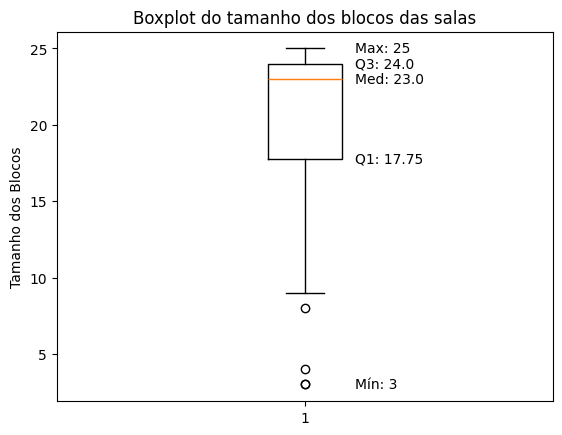

In [102]:
# Supondo que você já tem suas listas:
listas = todos_os_dicts1 + todos_os_dicts3 + todos_os_dicts7 + todos_os_dicts9
tamanhos = [len(d) for d in listas]
print(tamanhos)

# Calculando estatísticas
q1 = np.percentile(tamanhos, 25)
mediana = np.median(tamanhos)
q3 = np.percentile(tamanhos, 75)
minimo = np.min(tamanhos)
maximo = np.max(tamanhos)

print(f"Mínimo: {minimo}")
print(f"Q1 (25%): {q1}")
print(f"Mediana (50%): {mediana}")
print(f"Q3 (75%): {q3}")
print(f"Máximo: {maximo}")

# Fazendo o boxplot
plt.boxplot(tamanhos)
plt.ylabel("Tamanho dos Blocos")
plt.title("Boxplot do tamanho dos blocos das salas")

# Adicionando as estatísticas no gráfico
plt.text(1.1, minimo, f'Mín: {minimo}', va='center')
plt.text(1.1, q1, f'Q1: {q1}', va='center')
plt.text(1.1, mediana, f'Med: {mediana}', va='center')
plt.text(1.1, q3, f'Q3: {q3}', va='center')
plt.text(1.1, maximo, f'Max: {maximo}', va='center')

plt.show()